# <img style="float: left; padding-right: 10px; width: 250px" src="https://extension.harvard.edu/wp-content/uploads/sites/8/2020/08/image-10.png"> 
### Data Science Capstone Project
### NASA + Smithsonian Team Blue


## **Spring 2026**<br/>

<hr style="height:2pt">

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
from pathlib import Path

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## (a)	Import merged AGB/EO data 


In [4]:
file_path = "C:/Users/svazq/HES/Capstone/Merged_Data/AGB_EO_SENTINEL.csv"   

df = pd.read_csv(file_path)

print(df.head())

      dataset       plot_id  start_date    end_date  latitude_x  longitude_x  \
0  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
1  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
2  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
3  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
4  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   

   diameter  height species  plant_AGB_kg  longitude_y  latitude_y  \
0      26.3    12.0  mangle    630.627596    -88.60437    13.22736   
1      28.6    14.0  mangle    784.223246    -88.60437    13.22736   
2      19.2     4.0  mangle    139.136548    -88.60437    13.22736   
3       6.2     8.0  mangle     14.726733    -88.60437    13.22736   
4       5.2     5.0  mangle      9.321734    -88.60437    13.22736   

                  time    Blue   Green     Red     NIR   SWIR1   SWIR2  \
0  2017-01-12 16:16:21  

In [5]:
print("Shape:", df.shape)
df.head()

Shape: (8774, 24)


,dataset,plot_id,start_date,end_date,latitude_x,longitude_x,diameter,height,species,plant_AGB_kg,longitude_y,latitude_y,time,Blue,Green,Red,NIR,SWIR1,SWIR2,NDVI,MNDWI,NBR,EVI,CLOUD_COVERAGE
0,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,26.3,12.0,mangle,630.627596,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
1,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,28.6,14.0,mangle,784.223246,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
2,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,19.2,4.0,mangle,139.136548,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
3,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,6.2,8.0,mangle,14.726733,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
4,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,5.2,5.0,mangle,9.321734,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0


Data has tree-level rows with:

- tree variables: diameter, height, species
- EO values at a matched date: Blue, Green, Red, NIR, SWIR1, SWIR2, etc.
- target: plant_AGB_kg

The available EO inputs are spectral summaries matched to field observations rather than raw spatial image patches. Therefore, the current dataset supported tabular and dense neural network approaches, but not a CNN. A CNN would require retrieval of the underlying Sentinel imagery and extraction of fixed-size multi-band patches centered on each field location.


In [6]:
# Column names
print("\nColumns:")
print(df.columns.tolist())


Columns:
['dataset', 'plot_id', 'start_date', 'end_date', 'latitude_x', 'longitude_x', 'diameter', 'height', 'species', 'plant_AGB_kg', 'longitude_y', 'latitude_y', 'time', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE']


In [7]:
# Data types and missing values
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8774 entries, 0 to 8773
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dataset         8774 non-null   object 
 1   plot_id         8774 non-null   object 
 2   start_date      8774 non-null   object 
 3   end_date        8774 non-null   object 
 4   latitude_x      8774 non-null   float64
 5   longitude_x     8774 non-null   float64
 6   diameter        8774 non-null   float64
 7   height          8774 non-null   float64
 8   species         8774 non-null   object 
 9   plant_AGB_kg    8774 non-null   float64
 10  longitude_y     8160 non-null   float64
 11  latitude_y      8160 non-null   float64
 12  time            8160 non-null   object 
 13  Blue            8160 non-null   float64
 14  Green           8160 non-null   float64
 15  Red             8160 non-null   float64
 16  NIR             8160 non-null   float64
 17  SWIR1           8160 non-n

In [8]:
# Missing values by column
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
dataset             0
plot_id             0
start_date          0
end_date            0
latitude_x          0
longitude_x         0
diameter            0
height              0
species             0
plant_AGB_kg        0
longitude_y       614
latitude_y        614
time              614
Blue              614
Green             614
Red               614
NIR               614
SWIR1             614
SWIR2             614
NDVI              614
MNDWI             614
NBR               614
EVI               614
CLOUD_COVERAGE    614
dtype: int64


In [9]:
# Summary statistics for numeric columns
print("\nNumeric summary:")
print(df.describe())


Numeric summary:
        latitude_x  longitude_x     diameter       height  plant_AGB_kg  \
count  8774.000000  8774.000000  8774.000000  8774.000000   8774.000000   
mean     13.751943   -84.770866     8.455354   150.701767     80.498545   
std       4.887172    11.440609     8.756154   250.088842    371.881799   
min      -2.850264   -88.955557     0.210000     1.300000      0.000150   
25%      13.257775   -88.655700     3.000000     7.000000      0.028194   
50%      15.801897   -88.328149     6.000000    15.000000      8.018341   
75%      16.644709   -87.812320    10.000000   210.000000     31.045675   
max      18.342280   -40.031187    92.700000  3880.000000  11337.300329   

       longitude_y   latitude_y         Blue        Green          Red  \
count  8160.000000  8160.000000  8160.000000  8160.000000  8160.000000   
mean    -86.036726    14.423799     0.010618     0.033628     0.019640   
std       9.646012     4.175245     0.008208     0.010555     0.012194   
min     -8

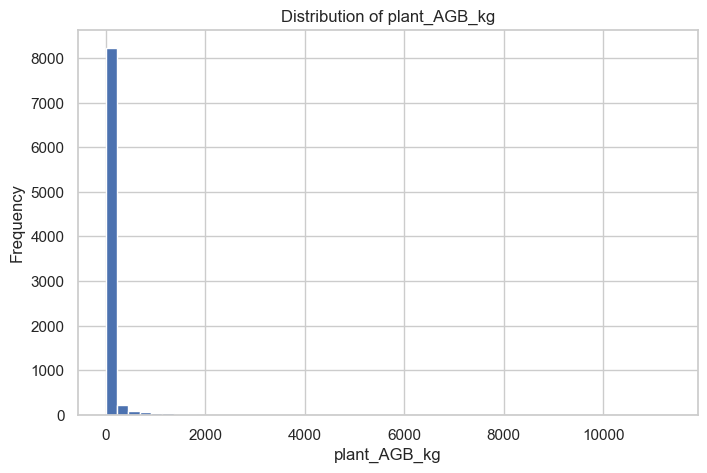

In [10]:
# Target distribution
plt.figure(figsize=(8, 5))
plt.hist(df["plant_AGB_kg"], bins=50)
plt.title("Distribution of plant_AGB_kg")
plt.xlabel("plant_AGB_kg")
plt.ylabel("Frequency")
plt.show()

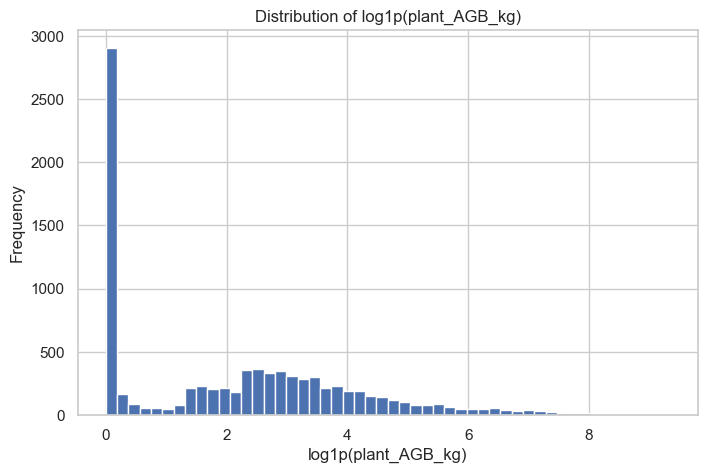

In [11]:
# log-transformed target distribution
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["plant_AGB_kg"]), bins=50)
plt.title("Distribution of log1p(plant_AGB_kg)")
plt.xlabel("log1p(plant_AGB_kg)")
plt.ylabel("Frequency")
plt.show()

In [12]:
eo_cols = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
    "NDVI", "MNDWI", "NBR", "EVI", "CLOUD_COVERAGE"
]

# Count unique EO combinations per plot
eo_variation = df.groupby("plot_id")[eo_cols].nunique()

print(eo_variation.head(10))

                      Blue  Green  Red  NIR  SWIR1  SWIR2  NDVI  MNDWI  NBR  \
plot_id                                                                       
ACA_Acarau Boca          3      4    3    3      3      4     5      6    5   
Arco_del_Espino_18_1     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_2     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_3     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_4     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_5     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_6     1      1    1    1      1      1     1      1    1   
BAR_Barreto              5      5    5    5      5      6     6      6    6   
BOC_Boca Grande          0      0    0    0      0      0     0      0    0   
Batipa_2                 0      0    0    0      0      0     0      0    0   

                      EVI  CLOUD_COVERAGE  
plot_id

In [13]:
# EO aggregation
eo_cols = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
    "NDVI", "MNDWI", "NBR", "EVI", "CLOUD_COVERAGE"
]

# Aggregate EO per plot (mean)
eo_agg = df.groupby("plot_id")[eo_cols].mean().reset_index()

# Merge back to original dataset
df_model = df.merge(eo_agg, on="plot_id", suffixes=("", "_agg"))

print(df_model.head())
print(df_model.shape)

      dataset       plot_id  start_date    end_date  latitude_x  longitude_x  \
0  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
1  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
2  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
3  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
4  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   

   diameter  height species  plant_AGB_kg  longitude_y  latitude_y  \
0      26.3    12.0  mangle    630.627596    -88.60437    13.22736   
1      28.6    14.0  mangle    784.223246    -88.60437    13.22736   
2      19.2     4.0  mangle    139.136548    -88.60437    13.22736   
3       6.2     8.0  mangle     14.726733    -88.60437    13.22736   
4       5.2     5.0  mangle      9.321734    -88.60437    13.22736   

                  time    Blue   Green     Red     NIR   SWIR1   SWIR2  \
0  2017-01-12 16:16:21  

## (b)	Data preparation

Let's log-transform the target variable to reduce skewness

In [14]:
# Prepare the features for modeling
df = df_model.copy()

# Target (log transform)
df["AGB_log"] = np.log1p(df["plant_AGB_kg"])


In [15]:
# Tree Features
tree_cols = ["diameter", "height"]

# EO features
eo_cols_agg = [
    "Blue_agg", "Green_agg", "Red_agg", "NIR_agg", "SWIR1_agg", "SWIR2_agg", "NDVI_agg", "MNDWI_agg", "NBR_agg", "EVI_agg", "CLOUD_COVERAGE_agg"]

# Categorical
cat_cols = ["species", "dataset"]

In [16]:
# Encode categorical vars
from sklearn.preprocessing import LabelEncoder

le_species = LabelEncoder()
le_dataset = LabelEncoder()

df["species_enc"] = le_species.fit_transform(df["species"])
df["dataset_enc"] = le_dataset.fit_transform(df["dataset"])

In [17]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler_tree = StandardScaler()
scaler_eo = StandardScaler()

X_tree = scaler_tree.fit_transform(df[tree_cols])
X_eo = scaler_eo.fit_transform(df[eo_cols_agg])

X_species = df["species_enc"].values
X_dataset = df["dataset_enc"].values

y = df["AGB_log"].values

In [18]:
# train/test split 

plot_ids = df["plot_id"].unique()

train_plots, test_plots = train_test_split(plot_ids, test_size=0.2, random_state=42)

train_idx = df["plot_id"].isin(train_plots)
test_idx = df["plot_id"].isin(test_plots)

X_tree_train, X_tree_test = X_tree[train_idx], X_tree[test_idx]
X_eo_train, X_eo_test = X_eo[train_idx], X_eo[test_idx]
X_species_train, X_species_test = X_species[train_idx], X_species[test_idx]
X_dataset_train, X_dataset_test = X_dataset[train_idx], X_dataset[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

In [19]:
# train/val/test split by plot

plot_ids = df["plot_id"].unique()

train_plots, temp_plots = train_test_split(plot_ids, test_size=0.3, random_state=42)

val_plots, test_plots = train_test_split(temp_plots, test_size=0.5, random_state=42)

train_idx = df["plot_id"].isin(train_plots)
val_idx = df["plot_id"].isin(val_plots)
test_idx = df["plot_id"].isin(test_plots)

X_tree_train, X_tree_val, X_tree_test = X_tree[train_idx], X_tree[val_idx], X_tree[test_idx]
X_eo_train, X_eo_val, X_eo_test = X_eo[train_idx], X_eo[val_idx], X_eo[test_idx]
X_species_train, X_species_val, X_species_test = X_species[train_idx], X_species[val_idx], X_species[test_idx]
X_dataset_train, X_dataset_val, X_dataset_test = X_dataset[train_idx], X_dataset[val_idx], X_dataset[test_idx]

y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

## (c)	Modeling

## Model 1 -Baseline model


### Model Architecture 
Tree branch       → Dense layers

EO branch         → Dense layers

Categorical branch→ Embeddings

→ Concatenate
→ Dense layers
→ AGB prediction
#

In [20]:
# 1st branch (Tree features)
tree_input = layers.Input(shape=(2,), name="tree_input")
x_tree = layers.Dense(32, activation="relu")(tree_input)
x_tree = layers.Dense(16, activation="relu")(x_tree)

In [21]:
# 2nd branch (EO features)
eo_input = layers.Input(shape=(len(eo_cols_agg),), name="eo_input")
x_eo = layers.Dense(64, activation="relu")(eo_input)
x_eo = layers.Dense(32, activation="relu")(x_eo)

In [22]:
# Categorical embeddings
# species
species_input = layers.Input(shape=(1,), name="species_input")
species_emb = layers.Embedding(
    input_dim=df["species_enc"].nunique(),
    output_dim=4
)(species_input)
species_emb = layers.Flatten()(species_emb)

# dataset
dataset_input = layers.Input(shape=(1,), name="dataset_input")
dataset_emb = layers.Embedding(
    input_dim=df["dataset_enc"].nunique(),
    output_dim=3
)(dataset_input)
dataset_emb = layers.Flatten()(dataset_emb)

In [23]:
# fusion layer
combined = layers.concatenate([
    x_tree,
    x_eo,
    species_emb,
    dataset_emb
])

In [24]:
# Lets use regularization
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(combined)

x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)

output = layers.Dense(1, activation="linear")(x)

In [25]:
# Model building
model_v1 = Model(
    inputs=[tree_input, eo_input, species_input, dataset_input],
    outputs=output
)

model_v1.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model_v1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tree_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eo_input            │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dataset_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │         96 │ tree_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        768 │ eo_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 4)      │         72 │ species_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 3)      │         51 │ dataset_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 55)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0],    │
│                     │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      7,168 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,084 (74.55 KB)

 Trainable params: 19,084 (74.55 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Training
history_v1 = model_v1.fit(
    [X_tree_train, X_eo_train, X_species_train, X_dataset_train],
    y_train,
    validation_data=(
        [X_tree_val, X_eo_val, X_species_val, X_dataset_val],
        y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
    ]
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.9427 - mae: 1.1657 - val_loss: 0.1260 - val_mae: 0.2663 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1055 - mae: 0.2146 - val_loss: 0.0791 - val_mae: 0.1859 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0799 - mae: 0.1920 - val_loss: 0.0690 - val_mae: 0.1787 - learning_rate: 0.0010
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0636 - mae: 0.1691 - val_loss: 0.0596 - val_mae: 0.1701 - learning_rate: 0.0010
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0575 - mae: 0.1624 - val_loss: 0.0547 - val_mae: 0.1676 - learning_rate: 0.0010
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0539 - mae: 0.1575 - val_loss: 0.0589 - val_mae: 0.1845 - learning_rate: 0.0010
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0509 - mae: 0.1590 - val_loss: 0.0503 - val_mae: 0.1755 - learning_rate: 0.0010
Epoch 

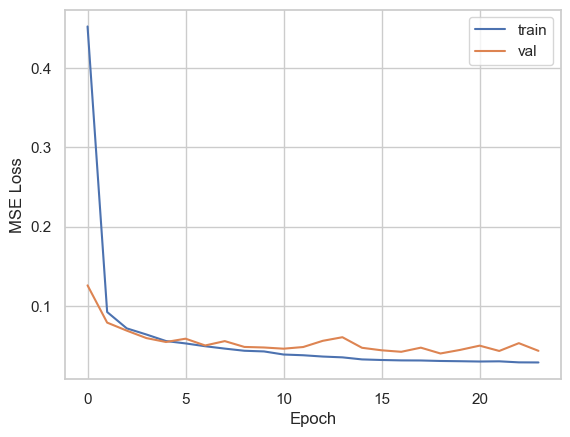

In [27]:
# Plot Plot train/validation loss
plt.plot(history_v1.history['loss'], label='train')
plt.plot(history_v1.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

The model converged well, with rapid initial improvement followed by steady refinement. Validation performance remained stable throughout training  indicating good generalization with only mild overfitting.

In [28]:
# Calculate Test performance metrics

y_pred_v1 = model_v1.predict([X_tree_test, X_eo_test, X_species_test, X_dataset_test])

y_pred_v1_real = np.expm1(y_pred_v1).ravel()
y_test_real = np.expm1(y_test)


rmse_v1 = np.sqrt(mean_squared_error(y_test_real, y_pred_v1_real))
mae_v1 = mean_absolute_error(y_test_real, y_pred_v1_real)
r2_v1 = r2_score(y_test_real, y_pred_v1_real)

print("RMSE:", rmse_v1)
print("MAE:", mae_v1)
print("R2:", r2_v1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
RMSE: 191.91739035639742
MAE: 31.455478187591115
R2: 0.7750389270868343


The model achieves strong predictive performance, explaining approximately 80% of the variance in the target variable. While average prediction error is relatively low, the higher RMSE compared to MAE suggests the presence of some large prediction errors, likely due to outliers or difficult-to-model observations.

In [29]:
# Fine tune regularization

def build_model(l2_value, tree_dim, eo_dim, species_dim, dataset_dim):
    tree_input = layers.Input(shape=(tree_dim,))
    eo_input = layers.Input(shape=(eo_dim,))
    species_input = layers.Input(shape=(species_dim,))
    dataset_input = layers.Input(shape=(dataset_dim,))

    combined = layers.concatenate([tree_input, eo_input, species_input, dataset_input])

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_value)
    )(combined)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_value)
    )(x)

    output = layers.Dense(1, activation="linear")(x)

    model = Model(
        inputs=[tree_input, eo_input, species_input, dataset_input],
        outputs=output
    )

    model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", RootMeanSquaredError(name="rmse")]
    )

    return model

In [30]:
l2_values = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]

In [31]:
# Reshape 1D inputs to 2D
X_species_train = X_species_train.reshape(-1, 1)
X_species_val = X_species_val.reshape(-1, 1)
X_species_test = X_species_test.reshape(-1, 1)

X_dataset_train = X_dataset_train.reshape(-1, 1)
X_dataset_val = X_dataset_val.reshape(-1, 1)
X_dataset_test = X_dataset_test.reshape(-1, 1)

# Dimensions
tree_dim = X_tree_train.shape[1]
eo_dim = X_eo_train.shape[1]
species_dim = X_species_train.shape[1]
dataset_dim = X_dataset_train.shape[1]


In [32]:

# Compute column means from training data only
eo_col_means = np.nanmean(X_eo_train, axis=0)

# Fill NaNs in train
inds_train = np.where(np.isnan(X_eo_train))
X_eo_train[inds_train] = np.take(eo_col_means, inds_train[1])

# Fill NaNs in validation using training means

In [33]:
results = []

for l2_val in l2_values:
    print(f"\nTraining model with L2 = {l2_val}")

    model = build_model(l2_val, tree_dim, eo_dim, species_dim, dataset_dim)

    history = model.fit(
        [X_tree_train, X_eo_train, X_species_train, X_dataset_train],
        y_train,
        validation_data=(
            [X_tree_val, X_eo_val, X_species_val, X_dataset_val],
            y_val
        ),
        epochs=50,
        batch_size=32,
        callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
        verbose=0
    )

    results.append({
        "l2": l2_val,
        "best_val_loss": min(history.history["val_loss"]),
        "best_val_mae": min(history.history["val_mae"]),
        "best_val_rmse": min(history.history["val_rmse"])        
    })

results_df = pd.DataFrame(results)
print(results_df)



Training model with L2 = 0.0

Training model with L2 = 1e-05

Training model with L2 = 0.0001

Training model with L2 = 0.001

Training model with L2 = 0.01
        l2  best_val_loss  best_val_mae  best_val_rmse
0  0.00000       1.059538      0.327251       1.029339
1  0.00001       1.165866      0.353184       1.078976
2  0.00010       1.050404      0.337949       1.019623
3  0.00100       0.855791      0.313748       0.909501
4  0.01000       0.470898      0.236494       0.654286


## Model 2 - Tuned

In [34]:

# Dense layers with best L2
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.01)
)(combined)

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.01)
)(x)

output = layers.Dense(1, activation="linear")(x)

# Model
model_v2 = Model(
    inputs=[tree_input, eo_input, species_input, dataset_input],
    outputs=output
)

# Compile 
model_v2.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=[
        "mae",
        RootMeanSquaredError(name="rmse")
    ]
)

In [35]:
model_v2.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tree_input          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eo_input            │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dataset_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │         96 │ tree_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        768 │ eo_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 4)      │         72 │ species_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 3)      │         51 │ dataset_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 55)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0],    │
│                     │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │      7,168 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      8,256 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1)         │         65 │ dense_23[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,084 (74.55 KB)

 Trainable params: 19,084 (74.55 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Training
history_v2 = model_v2.fit(
    [X_tree_train, X_eo_train, X_species_train, X_dataset_train],
    y_train,
    validation_data=(
        [X_tree_val, X_eo_val, X_species_val, X_dataset_val],
        y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
    ]
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.4954 - mae: 0.7844 - rmse: 1.2506 - val_loss: 0.2476 - val_mae: 0.2042 - val_rmse: 0.3226 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1951 - mae: 0.1826 - rmse: 0.3073 - val_loss: 0.1191 - val_mae: 0.1627 - val_rmse: 0.2737 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1131 - mae: 0.1746 - rmse: 0.3033 - val_loss: 0.0957 - val_mae: 0.1972 - val_rmse: 0.3067 - learning_rate: 0.0010
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0808 - mae: 0.1580 - rmse: 0.2752 - val_loss: 0.0681 - val_mae: 0.1581 - val_rmse: 0.2562 - learning_rate: 0.0010
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0703 - mae: 0.1632 - rmse: 0.2824 - val_loss: 0.0683 - val_mae: 0.1740 - val_rmse: 0.2854 - learning_rate: 0.0010
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0617 - mae: 0.1607 - rmse: 0.2718 - val_loss: 0.0795 - val

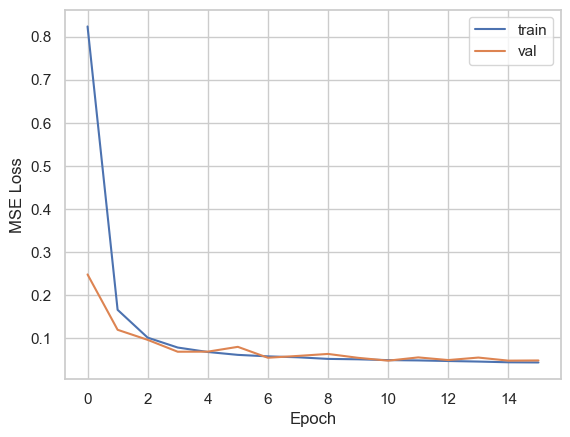

In [37]:
# Plot Plot train/validation loss
plt.plot(history_v2.history['loss'], label='train')
plt.plot(history_v2.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

The model converges quickly and maintains stable validation performance. Learning rate decay improves final generalization, and the small gap between training and validation metrics indicates effective regularization without significant overfitting.

In [38]:
# Calculate Test performance metrics

y_pred_v2 = model_v2.predict([X_tree_test, X_eo_test, X_species_test, X_dataset_test])

y_pred_v2_real = np.expm1(y_pred_v2).ravel()
y_test_real = np.expm1(y_test)


rmse_v2 = np.sqrt(mean_squared_error(y_test_real, y_pred_v2_real))
mae_v2 = mean_absolute_error(y_test_real, y_pred_v2_real)
r2_v2 = r2_score(y_test_real, y_pred_v2_real)

print("RMSE:", rmse_v2)
print("MAE:", mae_v2)
print("R2:", r2_v2)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
RMSE: 295.27353341429324
MAE: 41.730037927332916
R2: 0.4674900123914698


## Model 3 - Additional features (interaction and log features)

In [39]:
df_v3 = df_model.copy()

# Target (log)
df_v3["AGB_log"] = np.log1p(df_v3["plant_AGB_kg"])

# Engineered features
df_v3["dbh_height"] = df_v3["diameter"] * df_v3["height"]
df_v3["dbh_sq"] = df_v3["diameter"] ** 2
df_v3["log_diameter"] = np.log1p(df_v3["diameter"])
df_v3["log_height"] = np.log1p(df_v3["height"])

In [40]:
# Define feature groups
tree_cols_v3 = [
    "diameter",
    "height",
    "dbh_height",
    "dbh_sq",
    "log_diameter",
    "log_height"
]

eo_cols_agg = [
    "Blue_agg", "Green_agg", "Red_agg", "NIR_agg",
    "SWIR1_agg", "SWIR2_agg",
    "NDVI_agg", "MNDWI_agg", "NBR_agg", "EVI_agg",
    "CLOUD_COVERAGE_agg"
]

In [41]:
# Encode categorical variables 
le_species_v3 = LabelEncoder()
le_dataset_v3 = LabelEncoder()

df_v3["species_enc"] = le_species_v3.fit_transform(df_v3["species"]).astype("int32")
df_v3["dataset_enc"] = le_dataset_v3.fit_transform(df_v3["dataset"]).astype("int32")

In [42]:
# Clean data
df_v3 = df_v3.replace([np.inf, -np.inf], np.nan)

required_cols = tree_cols_v3 + eo_cols_agg + [
    "species_enc", "dataset_enc", "AGB_log", "plot_id"
]

df_v3 = df_v3.dropna(subset=required_cols).copy()

print("Shape after cleaning:", df_v3.shape)

Shape after cleaning: (8160, 42)


In [43]:
# Prepare inputs

scaler_tree_v3 = StandardScaler()
scaler_eo_v3 = StandardScaler()

X_tree_v3 = scaler_tree_v3.fit_transform(df_v3[tree_cols_v3])
X_eo_v3 = scaler_eo_v3.fit_transform(df_v3[eo_cols_agg])

X_species_v3 = df_v3["species_enc"].values.reshape(-1, 1)
X_dataset_v3 = df_v3["dataset_enc"].values.reshape(-1, 1)

y_v3 = df_v3["AGB_log"].values

In [44]:
# Safety checks 

print("NaNs in X_tree:", np.isnan(X_tree_v3).sum())
print("NaNs in X_eo:", np.isnan(X_eo_v3).sum())
print("NaNs in y:", np.isnan(y_v3).sum())

NaNs in X_tree: 0
NaNs in X_eo: 0
NaNs in y: 0


In [45]:
# Split by plot_id

plot_ids = df_v3["plot_id"].unique()

train_plots, temp_plots = train_test_split(
    plot_ids, test_size=0.3, random_state=42
)

val_plots, test_plots = train_test_split(
    temp_plots, test_size=0.5, random_state=42
)

train_idx_v3 = df_v3["plot_id"].isin(train_plots)
val_idx_v3 = df_v3["plot_id"].isin(val_plots)
test_idx_v3 = df_v3["plot_id"].isin(test_plots)

In [46]:
# Split arrays
X_tree_train_v3 = X_tree_v3[train_idx_v3]
X_tree_val_v3 = X_tree_v3[val_idx_v3]
X_tree_test_v3 = X_tree_v3[test_idx_v3]

X_eo_train_v3 = X_eo_v3[train_idx_v3]
X_eo_val_v3 = X_eo_v3[val_idx_v3]
X_eo_test_v3 = X_eo_v3[test_idx_v3]

X_species_train_v3 = X_species_v3[train_idx_v3]
X_species_val_v3 = X_species_v3[val_idx_v3]
X_species_test_v3 = X_species_v3[test_idx_v3]

X_dataset_train_v3 = X_dataset_v3[train_idx_v3]
X_dataset_val_v3 = X_dataset_v3[val_idx_v3]
X_dataset_test_v3 = X_dataset_v3[test_idx_v3]

y_train_v3 = y_v3[train_idx_v3]
y_val_v3 = y_v3[val_idx_v3]
y_test_v3 = y_v3[test_idx_v3]

In [47]:
# Embedding sizes
n_species_v3 = int(df_v3["species_enc"].max()) + 1
n_dataset_v3 = int(df_v3["dataset_enc"].max()) + 1

print("n_species:", n_species_v3)
print("n_dataset:", n_dataset_v3)

n_species: 18
n_dataset: 15


In [48]:
# Build model_v3

tree_input = layers.Input(shape=(len(tree_cols_v3),))
x_tree = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.01))(tree_input)
x_tree = layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x_tree)

eo_input = layers.Input(shape=(len(eo_cols_agg),))
x_eo = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.01))(eo_input)
x_eo = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x_eo)

species_input = layers.Input(shape=(1,))
species_emb = layers.Embedding(n_species_v3, 4)(species_input)
species_emb = layers.Flatten()(species_emb)

dataset_input = layers.Input(shape=(1,))
dataset_emb = layers.Embedding(n_dataset_v3, 3)(dataset_input)
dataset_emb = layers.Flatten()(dataset_emb)

combined = layers.concatenate([x_tree, x_eo, species_emb, dataset_emb])

x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01))(combined)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x)

output = layers.Dense(1, activation="linear")(x)

model_v3 = Model(
    inputs=[tree_input, eo_input, species_input, dataset_input],
    outputs=output
)

model_v3.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model_v3.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_21      │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_22      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_23      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32)        │        224 │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 64)        │        768 │ input_layer_21[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 4)      │         72 │ input_layer_22[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 3)      │         45 │ input_layer_23[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 16)        │        528 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 32)        │      2,080 │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 4)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 3)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 55)        │          0 │ dense_26[0][0],   │
│ (Concatenate)       │                   │            │ dense_28[0][0],   │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 128)       │      7,168 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 64)        │      8,256 │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 1)         │         65 │ dense_30[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,206 (75.02 KB)

 Trainable params: 19,206 (75.02 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Model training
history_v3 = model_v3.fit(
    [X_tree_train_v3, X_eo_train_v3, X_species_train_v3, X_dataset_train_v3],
    y_train_v3,
    validation_data=(
        [X_tree_val_v3, X_eo_val_v3, X_species_val_v3, X_dataset_val_v3],
        y_val_v3
    ),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
    ]
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.4670 - mae: 1.0322 - val_loss: 0.6337 - val_mae: 0.2684 - learning_rate: 0.0010
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4825 - mae: 0.1796 - val_loss: 0.2761 - val_mae: 0.2221 - learning_rate: 0.0010
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2285 - mae: 0.1702 - val_loss: 0.1787 - val_mae: 0.2082 - learning_rate: 0.0010
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1543 - mae: 0.1625 - val_loss: 0.1401 - val_mae: 0.2115 - learning_rate: 0.0010
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1255 - mae: 0.1686 - val_loss: 0.1296 - val_mae: 0.2230 - learning_rate: 0.0010
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1074 - mae: 0.1635 - val_loss: 0.1163 - val_mae: 0.2141 - learning_rate: 0.0010
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0979 - mae: 0.1580 - val_loss: 0.1073 - val_mae: 0.2035 - learning_rate: 0.0010
Epoch 

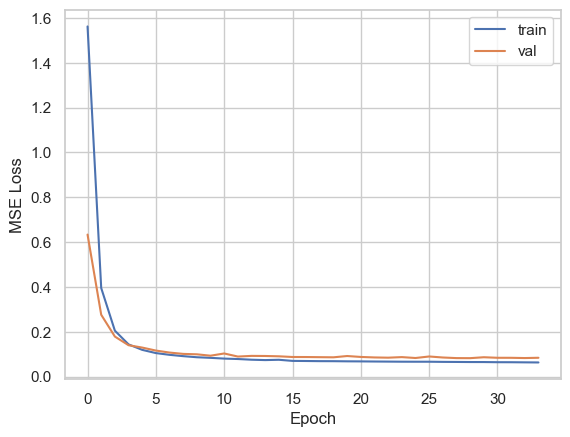

In [50]:
# Plot Plot train/validation loss
plt.plot(history_v3.history['loss'], label='train')
plt.plot(history_v3.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [51]:
# Calculate Test performance metrics

y_pred_v3_log = model_v3.predict(
    [X_tree_test_v3, X_eo_test_v3, X_species_test_v3, X_dataset_test_v3]
).ravel()

y_pred_v3 = np.expm1(y_pred_v3_log)
y_test_real = np.expm1(y_test_v3)

rmse_v3 = np.sqrt(mean_squared_error(y_test_real, y_pred_v3))
mae_v3 = mean_absolute_error(y_test_real, y_pred_v3)
r2_v3 = r2_score(y_test_real, y_pred_v3)

print("Model v3 RMSE:", rmse_v3)
print("Model v3 MAE:", mae_v3)
print("Model v3 R2:", r2_v3)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Model v3 RMSE: 198.31059139557877
Model v3 MAE: 41.495191041892255
Model v3 R2: 0.832024064274183


The model shows stable convergence with no signs of overfitting.  The close alignment between training and validation trends suggests strong generalization,.

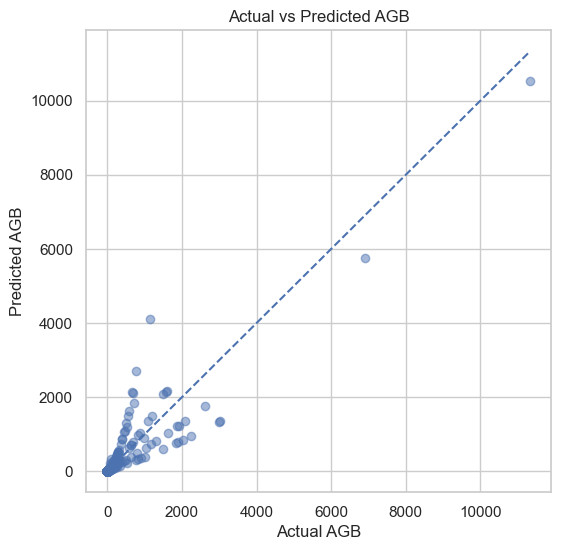

In [52]:
# Scatter: actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test_real, y_pred_v3, alpha=0.5)
plt.plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    linestyle="--"
)
plt.xlabel("Actual AGB")
plt.ylabel("Predicted AGB")
plt.title("Actual vs Predicted AGB")
plt.show()


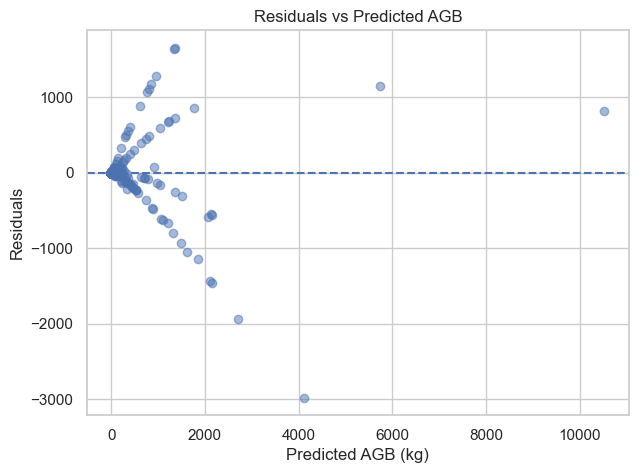

In [53]:
# Residual plot
residuals = y_test_real - y_pred_v3

plt.figure(figsize=(7,5))
plt.scatter(y_pred_v3, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted AGB (kg)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted AGB")
plt.show()



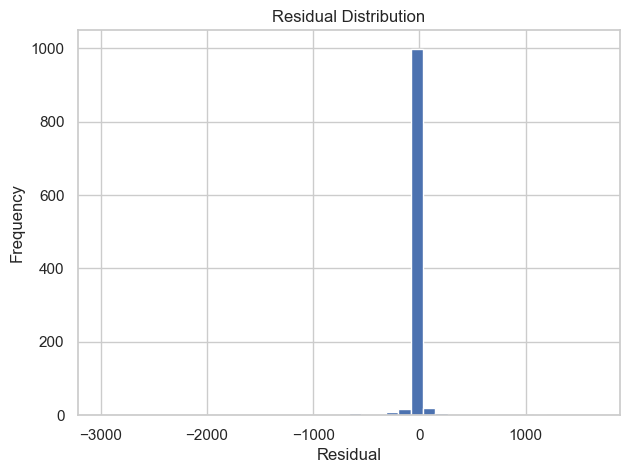

In [54]:
# Histogram of residuals
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=40)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

The model performs well across the majority of observations but exhibits systematic underestimation for high-biomass trees, indicating that extreme values remain challenging to predict even with engineered features and log-transformed targets.

In [55]:
# Check outliers
df_v3.nlargest(20, "plant_AGB_kg")[[
    "dataset", "plot_id", "species", "diameter", "height", "plant_AGB_kg"
]]

,dataset,plot_id,species,diameter,height,plant_AGB_kg
323,ElSalvador,Montecristo_22_3,racemosa,79.9,32.0,11337.300329
329,ElSalvador,Montecristo_22_2,racemosa,75.0,30.0,9617.170376
8686,Brazil-11,CAE_Caetano,Avicennia germinans,92.7,7.0,7364.095257
166,ElSalvador,Samuria_19_2,racemosa,66.0,30.0,6897.667533
278,ElSalvador,Montecristo_21_3,racemosa,61.6,28.0,5764.980954
1935,ElSalvador,El_Plan_de_la_Ceiba_8_6,racemosa,61.6,25.0,5764.980954
8716,Brazil-11,CAE_Caetano,Avicennia germinans,80.5,7.0,5248.535615
1978,ElSalvador,El_Plan_de_la_Ceiba_8_1,racemosa,59.2,28.0,5199.055609
1933,ElSalvador,El_Plan_de_la_Ceiba_8_6,racemosa,59.1,25.0,5176.252765
8705,Brazil-11,CAE_Caetano,Avicennia germinans,79.0,7.0,5016.872395


This shows mangrove species capable of high biomass such as:
- racemosa
- Avicennia germinans
- Rhizophora mangle

These are:
- Not data errors
- Not outliers in the bad sense
- Important ecological observations


## Model 4 - Weighted model

In [56]:
#Use raw AGB for weights,
agb_train_raw = np.expm1(y_train_v3)

sample_weights_v4 = 1.0 + (agb_train_raw / np.percentile(agb_train_raw, 90))
sample_weights_v4 = np.clip(sample_weights_v4, 1.0, 5.0)

print("Weight range:", sample_weights_v4.min(), sample_weights_v4.max())

Weight range: 1.0000020311819722 5.0


In [57]:
# Use same architecture as v3
model_v4 = model_v3  

history_v4 = model_v4.fit(
    [X_tree_train_v3, X_eo_train_v3, X_species_train_v3, X_dataset_train_v3],
    y_train_v3,
    sample_weight=sample_weights_v4,
    validation_data=(
        [X_tree_val_v3, X_eo_val_v3, X_species_val_v3, X_dataset_val_v3],
        y_val_v3
    ),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
    ]
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0888 - mae: 0.1443 - val_loss: 0.0870 - val_mae: 0.2053 - learning_rate: 9.0000e-05
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0859 - mae: 0.1417 - val_loss: 0.0869 - val_mae: 0.2029 - learning_rate: 9.0000e-05
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0829 - mae: 0.1401 - val_loss: 0.0855 - val_mae: 0.1971 - learning_rate: 9.0000e-05
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0797 - mae: 0.1352 - val_loss: 0.0836 - val_mae: 0.1932 - learning_rate: 9.0000e-05
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0828 - mae: 0.1360 - val_loss: 0.0880 - val_mae: 0.2023 - learning_rate: 9.0000e-05
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0806 - mae: 0.1373 - val_loss: 0.0840 - val_mae: 0.1927 - learning_rate: 9.0000e-05
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0812 - mae: 0.1359 - val_loss: 0.0835 - val_mae: 0.1905 - lear

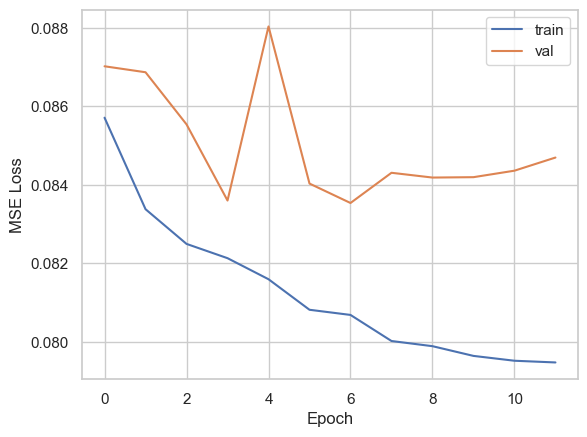

In [58]:
# Plot Plot train/validation loss
plt.plot(history_v4.history['loss'], label='train')
plt.plot(history_v4.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [59]:
# Eval
y_pred_v4_log = model_v4.predict(
    [X_tree_test_v3, X_eo_test_v3, X_species_test_v3, X_dataset_test_v3]
).ravel()

y_pred_v4 = np.expm1(y_pred_v4_log)
y_test_real = np.expm1(y_test_v3)

# Calculate Test performance metrics
rmse_v4 = np.sqrt(mean_squared_error(y_test_real, y_pred_v4))
mae_v4 = mean_absolute_error(y_test_real, y_pred_v4)
r2_v4 = r2_score(y_test_real, y_pred_v4)

print("Model v4 RMSE:", rmse_v4)
print("Model v4 MAE:", mae_v4)
print("Model v4 R2:", r2_v4)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Model v4 RMSE: 205.5836816527924
Model v4 MAE: 39.973019254607316
Model v4 R2: 0.819477005799623


The model shows limited improvement during training, with both training and validation metrics plateauing early. The small gap between training and validation performance indicates underfitting, suggesting that the model is overly constrained and unable to capture the underlying data patterns.

Over-weight strategy told the model to focus more on large trees causing:

- improved (slightly) on large trees
- sacrificed performance on the majority

While weighted loss was explored to improve prediction of high-biomass trees, it resulted in degraded overall model performance, indicating that emphasizing rare extreme observations introduces a trade-off that reduces general predictive accuracy

Weighted training did not resolve the underestimation of high-biomass trees and led to increased variance in predictions for the majority of observations, resulting in degraded overall performance

## Model comparison

Let's compare the performance metrics for the 4 models

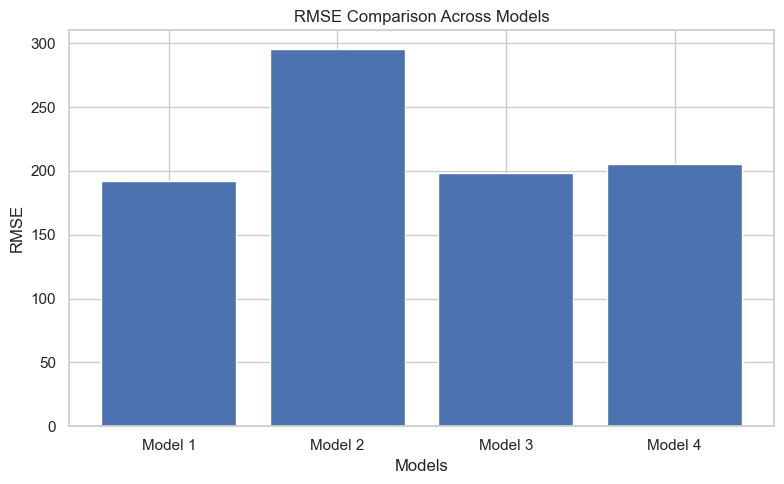

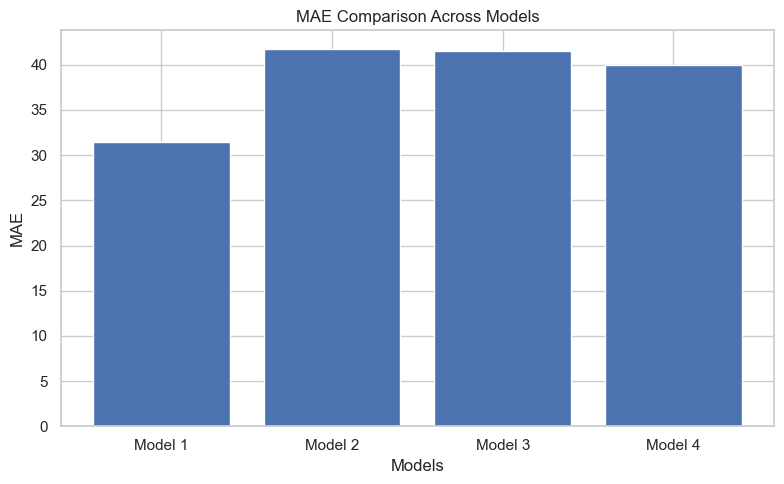

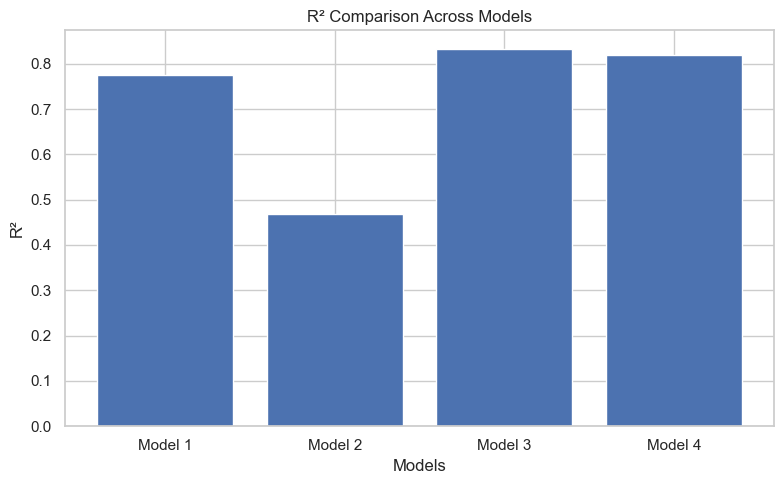

In [60]:
import matplotlib.pyplot as plt

# Model versions
models = ["Model 1", "Model 2", "Model 3", "Model 4"]

# Metrics using your variables
rmse = [rmse_v1, rmse_v2, rmse_v3, rmse_v4]
mae  = [mae_v1, mae_v2, mae_v3, mae_v4]
r2   = [r2_v1, r2_v2, r2_v3, r2_v4]

# --- RMSE ---
plt.figure(figsize=(8, 5))
plt.bar(models, rmse)
plt.title("RMSE Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- MAE ---
plt.figure(figsize=(8, 5))
plt.bar(models, mae)
plt.title("MAE Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- R² ---
plt.figure(figsize=(8, 5))
plt.bar(models, r2)
plt.title("R² Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("R²")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Model 3 achieved the best overall performance, with the highest R² and lowest RMSE, indicating strong predictive capability and variance explanation. Model 1 produced the lowest MAE, suggesting more consistent average predictions, but with lower overall fit. Model 4 provided a comparable alternative with slightly improved MAE but marginally lower R². Model 2 underperformed across all metrics, indicating underfitting.